# 12 — Inference-Data EDA, Drift & Performance Monitoring

**Purpose:** End-to-end exploratory analysis of the production model's weekly inference
output, consolidating the drift story (nb 09, the weekly classified CSVs, and memory
`project-drift-backfill-2026-05-17`) into one ordered notebook.

Covers AM2 criterion **S24** (model drift, data drift, performance monitoring) and
contributes to the **S22/S24 distinction** (robust monitoring + honest data-quality work).

**Data:** `data/modelling/weekly/classified_week_*.csv` — every article the production
model has classified, week by week. These are *prediction-only* files (no ground truth),
so any drift here is drift in the model's **predicted** distribution, not verified label drift.

**Structure**
- §0 Setup & load
- §1 Source inventory & junk flagging (data quality)
- §2 Split: all-sources vs real-sources
- §3 Volume EDA
- §4 Publisher EDA
- §5 Category EDA
- §6 Nation / Four Nations coverage
- §7 Confidence — top1
- §8 Combined / top2 confidence
- §9 Drift synthesis
- §10 Artefacts out

## §0 — Setup & load

In [1]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
WEEKLY_DIR = ROOT / "data" / "modelling" / "weekly"
OUT_DIR = ROOT / "outputs"; OUT_DIR.mkdir(exist_ok=True)
QUAL_DIR = ROOT / "data" / "quality"; QUAL_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 120)

In [2]:
# Load the latest classified data LIVE from Supabase (v_dashboard = the deployed model's
# output, joined with article metadata + scoring). Caches a CSV copy each run, and falls
# back to that cache if Supabase creds aren't available (offline / reproducible reruns).
import os
from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

LIVE_CSV = ROOT / "data" / "modelling" / "inference_classified_live.csv"

try:
    from supabase import create_client
    sb = create_client(os.environ["SUPABASE_URL"], os.environ["SUPABASE_SERVICE_KEY"])
    rows, step, off = [], 1000, 0
    while True:                                   # paginate (Supabase caps rows per request)
        r = sb.table("v_dashboard").select("*").range(off, off + step - 1).execute()
        rows += r.data
        if len(r.data) < step:
            break
        off += step
    all_df = pd.DataFrame(rows)
    all_df.to_csv(LIVE_CSV, index=False)          # cache for offline reruns
    print(f"Pulled {len(all_df)} rows LIVE from Supabase v_dashboard")
except Exception as e:
    all_df = pd.read_csv(LIVE_CSV)
    print(f"Supabase pull skipped ({type(e).__name__}); loaded cached {LIVE_CSV.name}: {len(all_df)} rows")

all_df["_week"] = all_df["week_number"].astype(int)
all_df["article_date"] = pd.to_datetime(all_df["article_date"])
all_df["_month"] = all_df["article_date"].dt.to_period("M").astype(str)

print(f"Weeks:           {all_df['_week'].min()}-{all_df['_week'].max()}")
print(f"Date span:       {all_df['article_date'].min().date()} -> {all_df['article_date'].max().date()}")
print(f"Unique sources:  {all_df['source'].nunique()}")
all_df[["source", "article_date", "top1", "top1_confidence", "top2", "top2_confidence", "_week", "_month"]].head()

Pulled 874 rows LIVE from Supabase v_dashboard
Weeks:           1-24
Date span:       2026-01-01 -> 2026-06-11
Unique sources:  45


,source,article_date,top1,top1_confidence,top2,top2_confidence,_week,_month
0,dfe,2026-06-11,None,NaN,None,NaN,24,2026-06
1,schoolsweek,2026-03-30,political_environment_key_organisations,0.412542,policy_practice_research,0.232809,13,2026-03
2,ucl_research_for_the_real_world_ioe_podcast,2026-05-11,policy_practice_research,0.398639,teacher_rrd,0.265709,19,2026-05
3,bbc.co.uk,2026-05-21,political_environment_key_organisations,0.279592,edtech,0.248862,21,2026-05
4,schoolsweek,2026-03-13,teacher_rrd,0.463943,political_environment_key_organisations,0.256688,11,2026-03


## §1 — Source inventory & junk flagging

> **Methodological insight — clean the sources before reading confidence.** Scraping quality
> directly affects drift monitoring: a burst of junk or a noisy newly-added source can drag
> mean confidence down and *masquerade* as model degradation. So source inventory and cleaning
> (this section) must run **before** any confidence/drift reading (§7-§9) — which is why this
> notebook is deliberately ordered source-first. The same pass doubles as a junk detector:
> whatever off-topic domains it surfaces feed the `relevance.py` blocklist.

In [3]:
# Full source inventory
inv = all_df["source"].value_counts().rename("n").to_frame()
print(f"{all_df['source'].nunique()} sources producing articles\n")
inv

45 sources producing articles



,n
source,
schoolsweek,338
gov_scot,71
belfast_telegraph,68
ascl,51
dfe,33
children_in_scotland,23
gov.uk,21
fft_datalab,19
fed,18


In [4]:
# Off-topic / dropped sources — excluded from the clean analysis set.
# (a) Alert-junk: arrived via Google Alerts, now in relevance.py BLOCKED_DOMAINS.
OFFTOPIC = {
    "e.vnexpress.net", "smh.com.au", "news.abplive.com",   # Vietnam / Australia / India
    "instagram.com", "tvguide.co.uk",                      # social / TV listings
    "msn.com", "pressreader.com", "uk.news.yahoo.com",     # aggregators
}
# (b) Curator-dropped 2026-06-11: tabloid / paywall. Scraper already drops all but one —
#     uknip.co.uk + mirror.co.uk in BLOCKED_DOMAINS, thetimes.com in PAYWALL_DOMAINS,
#     standard.co.uk added to BLOCKED_DOMAINS 2026-06-11.
CURATOR_DROPPED = {"mirror.co.uk", "uknip.co.uk", "thetimes.com", "standard.co.uk"}

DROPPED = OFFTOPIC | CURATOR_DROPPED
all_df["_offtopic"] = all_df["source"].isin(DROPPED)

n_drop = int(all_df["_offtopic"].sum())
print(f"Dropped rows: {n_drop} of {len(all_df)} ({n_drop/len(all_df)*100:.1f}%)")
all_df.loc[all_df["_offtopic"], ["source", "title", "_week"]]

Dropped rows: 0 of 874 (0.0%)


,source,title,_week


In [5]:
# Curator decision 2026-06-11: the tier-2 borderline domains are DROPPED (folded into
# CURATOR_DROPPED above). Scraper status: all are already dropped pre-scrape — standard.co.uk
# was the only one missing and is now in BLOCKED_DOMAINS.
all_df.loc[all_df["source"].isin(CURATOR_DROPPED), ["source", "title", "top1", "_week"]]

,source,title,top1,_week


## §2 — Split: all-sources vs real-sources

`all_df` stays as the full record (junk count survives as a QA stat). Every chart from
here on runs on `clean` — real sources only.

In [6]:
clean = all_df[~all_df["_offtopic"]].copy()
print(f"all_df: {len(all_df)} rows ({all_df['source'].nunique()} sources)")
print(f"clean:  {len(clean)} rows ({clean['source'].nunique()} sources)  <- analysis set")

all_df: 874 rows (45 sources)
clean:  874 rows (45 sources)  <- analysis set


## §3 — Volume EDA

In [7]:
# Week -> calendar date range, used to label time axes throughout.
wk = clean.groupby("_week")["article_date"].agg(start="min", end="max", n="size")
wk["start"] = wk["start"].dt.date
wk["end"] = wk["end"].dt.date
wk

,start,end,n
_week,,,
1,2026-01-01,2026-01-05,4
2,2026-01-07,2026-01-12,20
3,2026-01-13,2026-01-19,24
4,2026-01-20,2026-01-26,30
5,2026-01-27,2026-02-02,29
6,2026-02-03,2026-02-09,17
7,2026-02-10,2026-02-16,23
8,2026-02-17,2026-02-23,22
9,2026-02-24,2026-03-02,30


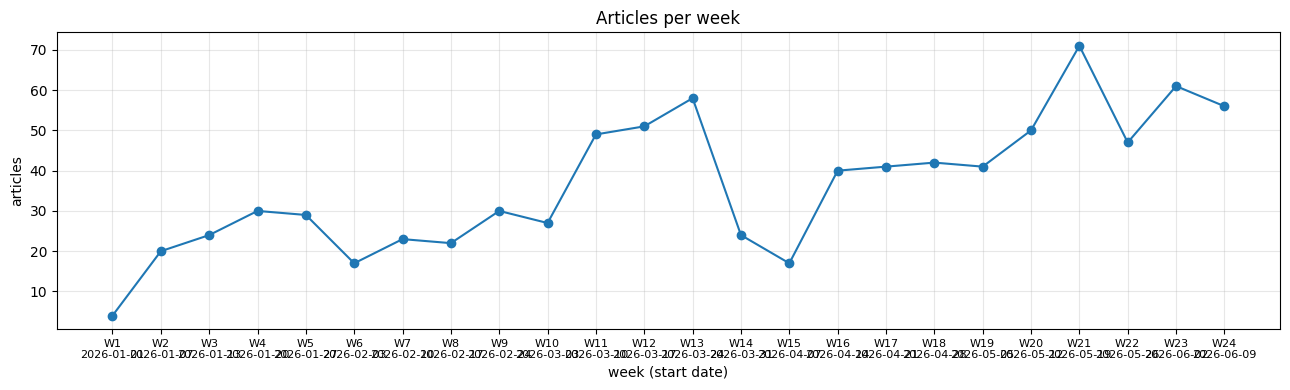

_week
1      4
2     20
3     24
4     30
5     29
6     17
7     23
8     22
9     30
10    27
11    49
12    51
13    58
14    24
15    17
16    40
17    41
18    42
19    41
20    50
21    71
22    47
23    61
24    56
dtype: int64

In [8]:
# Articles per week (line, labelled with the week's start date)
counts = clean.groupby("_week").size()
ax = counts.plot(figsize=(13, 4), marker="o", title="Articles per week")
ax.set_xticks(counts.index)
ax.set_xticklabels([f"W{w}\n{wk.loc[w, 'start']}" for w in counts.index], rotation=0, fontsize=8)
ax.set_ylabel("articles"); ax.set_xlabel("week (start date)"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
counts

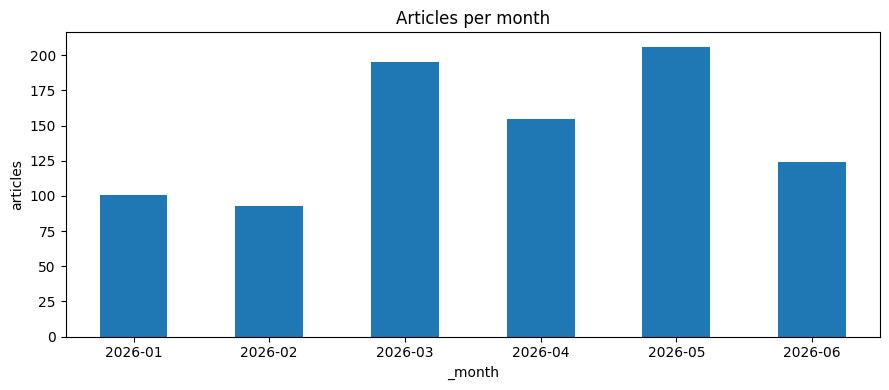

In [9]:
# Articles per month
clean.groupby("_month").size().plot(kind="bar", figsize=(9, 4), title="Articles per month")
plt.ylabel("articles"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

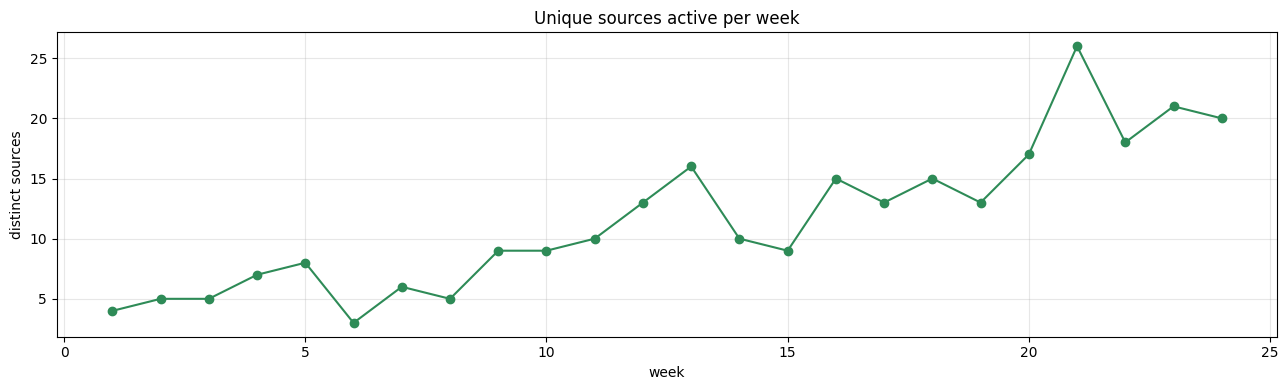

_week
1      4
2      5
3      5
4      7
5      8
6      3
7      6
8      5
9      9
10     9
11    10
12    13
13    16
14    10
15     9
16    15
17    13
18    15
19    13
20    17
21    26
22    18
23    21
24    20
Name: source, dtype: int64

In [10]:
# Unique sources per week — shows the volume growth is NEW sources switching on,
# not more articles from the same outlets.
src_per_week = clean.groupby("_week")["source"].nunique()
src_per_week.plot(figsize=(13, 4), marker="o", color="seagreen",
                  title="Unique sources active per week")
plt.ylabel("distinct sources"); plt.xlabel("week"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
src_per_week

## §4 — Publisher EDA

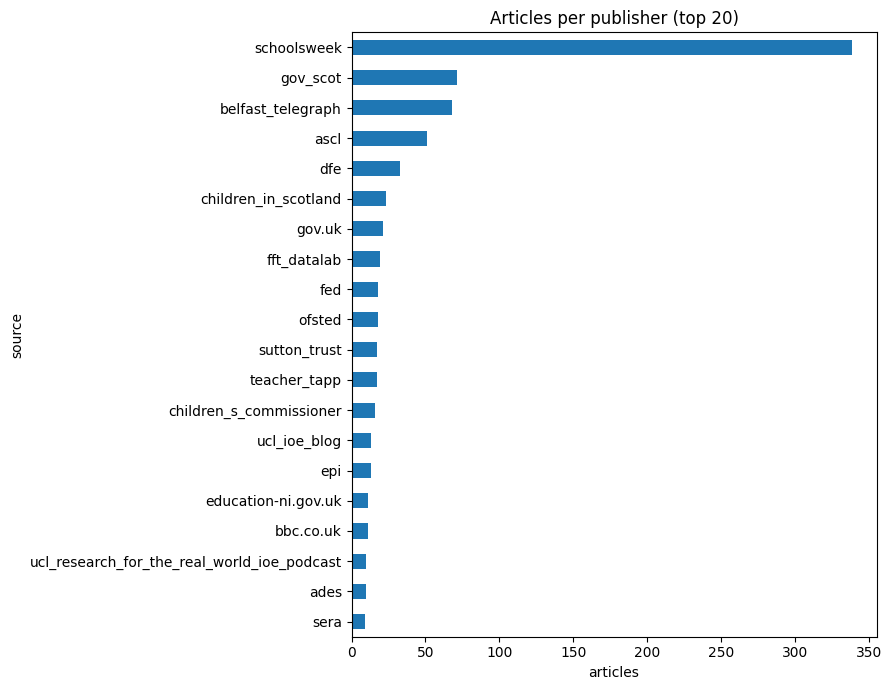

source
schoolsweek                                    338
gov_scot                                        71
belfast_telegraph                               68
ascl                                            51
dfe                                             33
children_in_scotland                            23
gov.uk                                          21
fft_datalab                                     19
fed                                             18
ofsted                                          18
sutton_trust                                    17
teacher_tapp                                    17
children_s_commissioner                         16
ucl_ioe_blog                                    13
epi                                             13
education-ni.gov.uk                             11
bbc.co.uk                                       11
ucl_research_for_the_real_world_ioe_podcast     10
ades                                            10
sera                    

In [11]:
# Top publishers overall
top_src = clean["source"].value_counts()
top_src.head(20).iloc[::-1].plot(kind="barh", figsize=(9, 7), title="Articles per publisher (top 20)")
plt.xlabel("articles"); plt.tight_layout(); plt.show()
top_src

In [12]:
# Category x publisher — which outlet feeds which category
# (e.g. is `four_nations` essentially just gov_scot?)
cat_pub = pd.crosstab(clean["source"], clean["top1"])
cat_pub.loc[top_src.head(15).index]

top1,edtech,four_nations,policy_practice_research,political_environment_key_organisations,teacher_rrd,what_matters_ed
source,,,,,,
schoolsweek,33,3,6,117,82,87
gov_scot,4,49,3,5,1,9
belfast_telegraph,4,23,2,7,13,17
ascl,5,3,0,21,8,12
dfe,4,2,3,14,1,8
children_in_scotland,2,21,0,0,0,0
gov.uk,1,1,2,11,0,4
fft_datalab,0,0,0,3,2,14
fed,4,1,2,2,1,8


## §5 — Category EDA

Raw counts are dominated by the rising total volume, so the **normalised** (proportion)
view is the one that actually shows category *mix* drift.

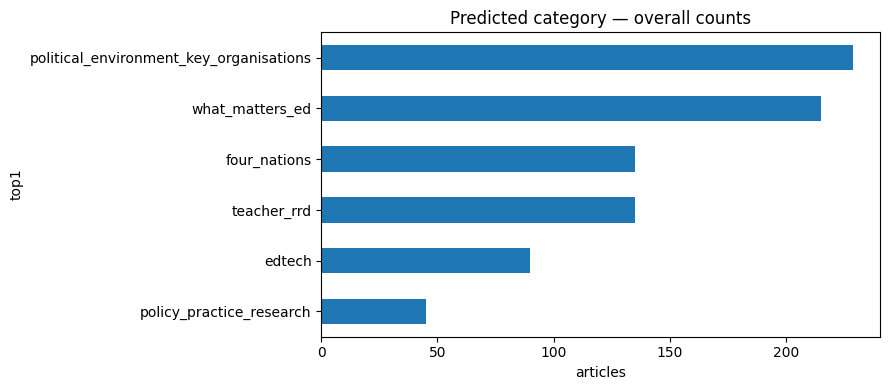

top1
political_environment_key_organisations    229
what_matters_ed                            215
four_nations                               135
teacher_rrd                                135
edtech                                      90
policy_practice_research                    45
Name: count, dtype: int64

In [13]:
# Category counts overall
clean["top1"].value_counts().iloc[::-1].plot(kind="barh", figsize=(9, 4),
                                             title="Predicted category — overall counts")
plt.xlabel("articles"); plt.tight_layout(); plt.show()
clean["top1"].value_counts()

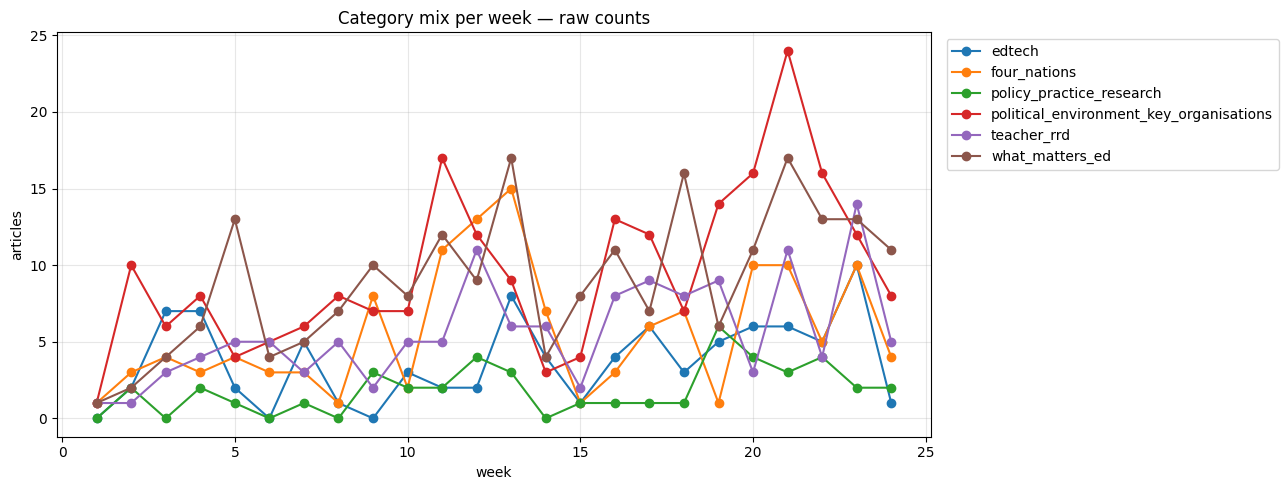

top1,edtech,four_nations,policy_practice_research,political_environment_key_organisations,teacher_rrd,what_matters_ed
_week,,,,,,
1,0,1,0,1,1,1
2,2,3,2,10,1,2
3,7,4,0,6,3,4
4,7,3,2,8,4,6
5,2,4,1,4,5,13
6,0,3,0,5,5,4
7,5,3,1,6,3,5
8,1,1,0,8,5,7
9,0,8,3,7,2,10


In [14]:
# Category per week — RAW counts (line)
cat_week = clean.groupby(["_week", "top1"]).size().unstack(fill_value=0)
cat_week.plot(figsize=(13, 5), marker="o", title="Category mix per week — raw counts")
plt.ylabel("articles"); plt.xlabel("week"); plt.legend(bbox_to_anchor=(1.01, 1))
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
cat_week

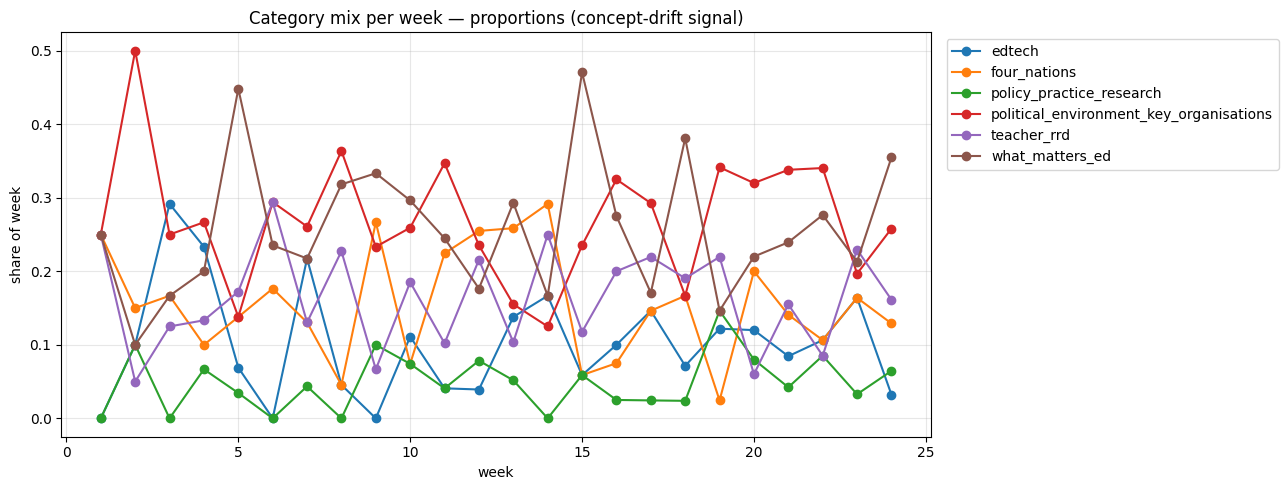

top1,edtech,four_nations,policy_practice_research,political_environment_key_organisations,teacher_rrd,what_matters_ed
_week,,,,,,
1,0.000,0.250,0.000,0.250,0.250,0.250
2,0.100,0.150,0.100,0.500,0.050,0.100
3,0.292,0.167,0.000,0.250,0.125,0.167
4,0.233,0.100,0.067,0.267,0.133,0.200
5,0.069,0.138,0.034,0.138,0.172,0.448
6,0.000,0.176,0.000,0.294,0.294,0.235
7,0.217,0.130,0.043,0.261,0.130,0.217
8,0.045,0.045,0.000,0.364,0.227,0.318
9,0.000,0.267,0.100,0.233,0.067,0.333


In [15]:
# Category per week — NORMALISED to proportions (the honest drift view)
cat_week_prop = cat_week.div(cat_week.sum(axis=1), axis=0)
cat_week_prop.plot(figsize=(13, 5), marker="o",
                   title="Category mix per week — proportions (concept-drift signal)")
plt.ylabel("share of week"); plt.xlabel("week"); plt.legend(bbox_to_anchor=(1.01, 1))
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUT_DIR / "drift_class_mix.png", dpi=120, bbox_inches="tight")
plt.show()
cat_week_prop.round(3)

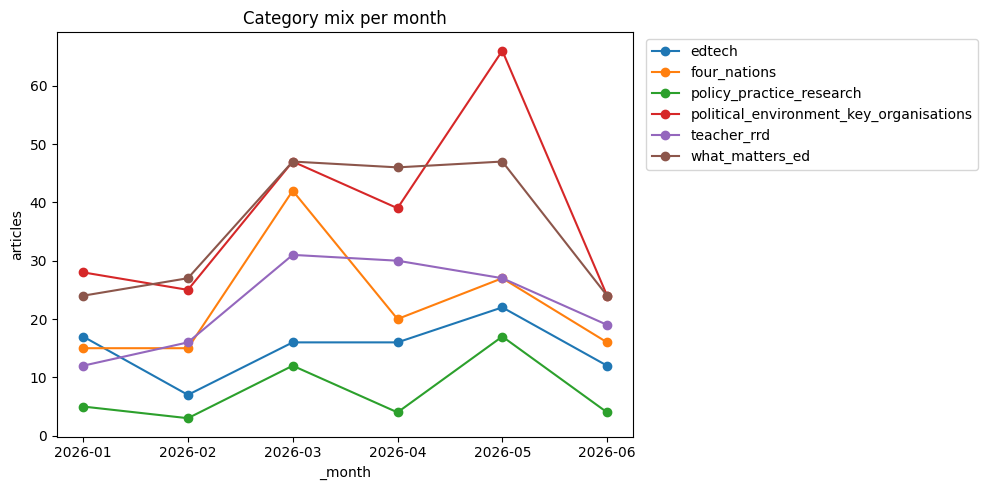

In [16]:
# Category per month
clean.groupby(["_month", "top1"]).size().unstack(fill_value=0).plot(
    figsize=(10, 5), marker="o", title="Category mix per month")
plt.ylabel("articles"); plt.legend(bbox_to_anchor=(1.01, 1)); plt.tight_layout(); plt.show()

## §6 — Nation / Four Nations coverage

The newsletter is meant to span all four UK nations. Mapping sources to nations exposes a
real coverage bias.

**Finding (documented, not fixed here):** Wales is configured in the scraper registry with
~12 feeds (Welsh Government / Senedd / WLGA etc.), but almost all return **zero** articles —
only `wales_centre_for_public_policy` produces anything (single digits). So the Four Nations
gap is a *yield* problem (feeds configured but silent), not a coverage-design gap. Fixing the
Welsh feeds is scraping-expansion work parked until after the AM2 write-up.

In [17]:
NATION = {
    # Scotland
    "gov_scot": "Scotland", "children_in_scotland": "Scotland", "ades": "Scotland",
    "sera": "Scotland", "scotland_digital_blog": "Scotland", "gtcs": "Scotland",
    "scotland_scottish_parliament_blog": "Scotland",
    # Wales
    "wales_centre_for_public_policy": "Wales",
    # N. Ireland
    "belfast_telegraph": "N. Ireland",
    # England-specific
    "dfe": "England", "ofsted": "England", "schoolsweek": "England", "ascl": "England",
}
clean["_nation"] = clean["source"].map(NATION).fillna("UK-wide/other")
clean["_nation"].value_counts()

_nation
England          440
UK-wide/other    241
Scotland         122
N. Ireland        68
Wales              3
Name: count, dtype: int64

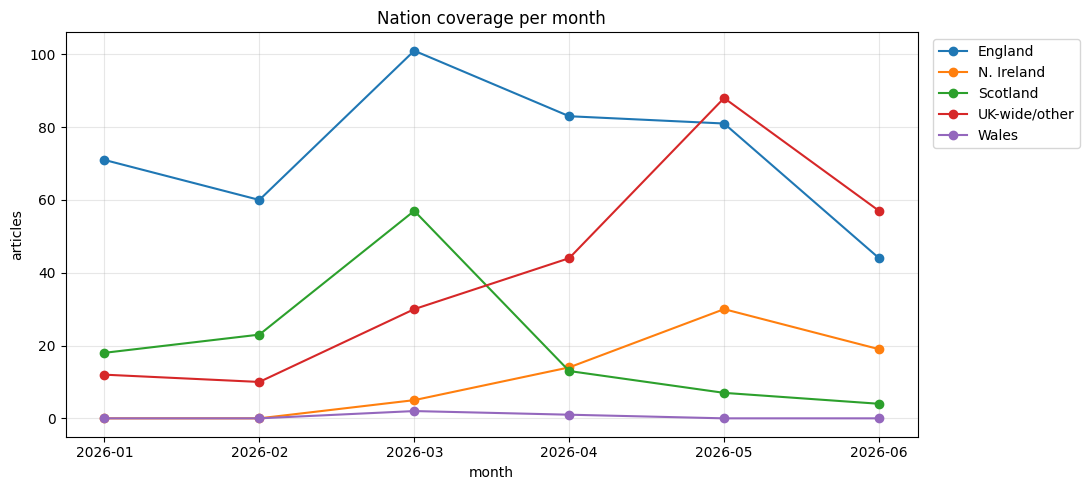

_nation,England,N. Ireland,Scotland,UK-wide/other,Wales
_month,,,,,
2026-01,71,0,18,12,0
2026-02,60,0,23,10,0
2026-03,101,5,57,30,2
2026-04,83,14,13,44,1
2026-05,81,30,7,88,0
2026-06,44,19,4,57,0


In [18]:
# Nation coverage per month (line, not stacked)
nat_month = clean.groupby(["_month", "_nation"]).size().unstack(fill_value=0)
nat_month.plot(figsize=(11, 5), marker="o", title="Nation coverage per month")
plt.ylabel("articles"); plt.xlabel("month"); plt.legend(bbox_to_anchor=(1.01, 1))
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
nat_month

## §7 — Confidence: top1

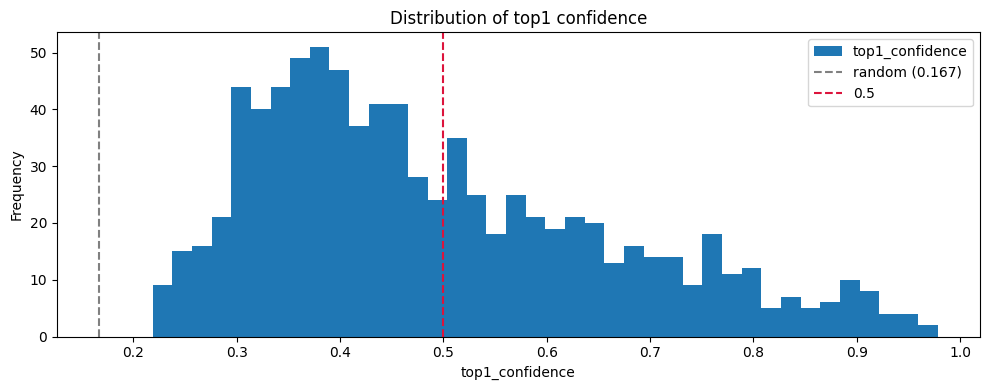

count    849.000
mean       0.494
std        0.172
min        0.219
25%        0.359
50%        0.452
75%        0.604
max        0.979
Name: top1_confidence, dtype: float64

In [19]:
# Distribution of top1 confidence (6 classes -> random baseline = 1/6 = 0.167)
clean["top1_confidence"].plot(kind="hist", bins=40, figsize=(10, 4),
                              title="Distribution of top1 confidence")
plt.axvline(1/6, color="grey", ls="--", label="random (0.167)")
plt.axvline(0.5, color="crimson", ls="--", label="0.5")
plt.xlabel("top1_confidence"); plt.legend(); plt.tight_layout(); plt.show()
clean["top1_confidence"].describe().round(3)

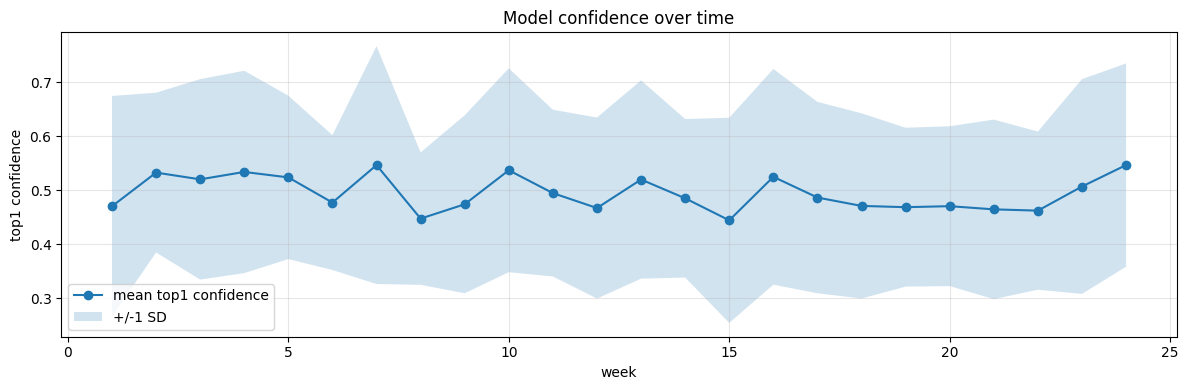

Week 1 = 0.471  ->  week 24 = 0.547


In [20]:
# Mean top1 confidence per week, with +/-1 SD band
wc = clean.groupby("_week")["top1_confidence"].agg(["mean", "std"])
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(wc.index, wc["mean"], marker="o", label="mean top1 confidence")
ax.fill_between(wc.index, wc["mean"] - wc["std"], wc["mean"] + wc["std"], alpha=0.2, label="+/-1 SD")
ax.set_xlabel("week"); ax.set_ylabel("top1 confidence")
ax.set_title("Model confidence over time"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(OUT_DIR / "drift_confidence_over_time.png", dpi=120); plt.show()
print(f"Week {wc.index.min()} = {wc['mean'].iloc[0]:.3f}  ->  week {wc.index.max()} = {wc['mean'].iloc[-1]:.3f}")

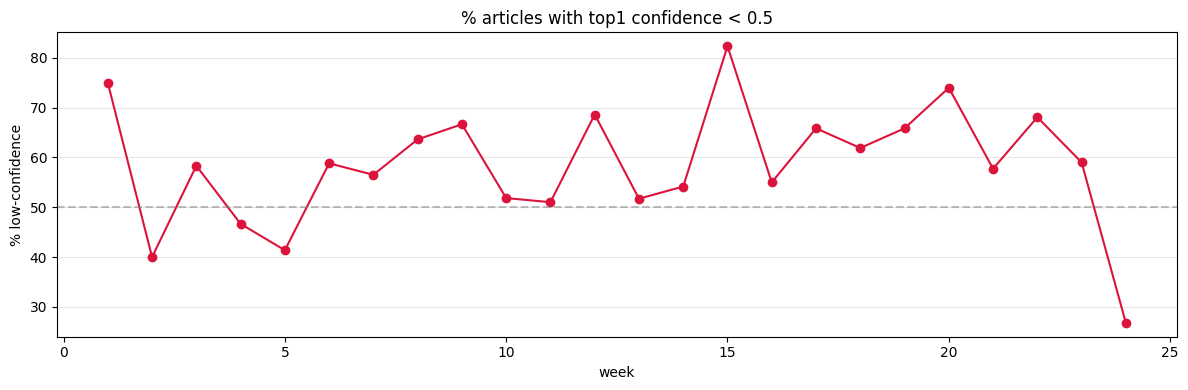

Start: 75.0%   End: 26.8%


In [21]:
# % of articles below 0.5 confidence per week
low_conf = (clean["top1_confidence"] < 0.5).groupby(clean["_week"]).mean() * 100
low_conf.plot(figsize=(12, 4), marker="o", color="crimson",
              title="% articles with top1 confidence < 0.5")
plt.axhline(50, color="grey", ls="--", alpha=0.5)
plt.ylabel("% low-confidence"); plt.xlabel("week"); plt.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.savefig(OUT_DIR / "drift_low_confidence_pct.png", dpi=120); plt.show()
print(f"Start: {low_conf.iloc[0]:.1f}%   End: {low_conf.iloc[-1]:.1f}%")

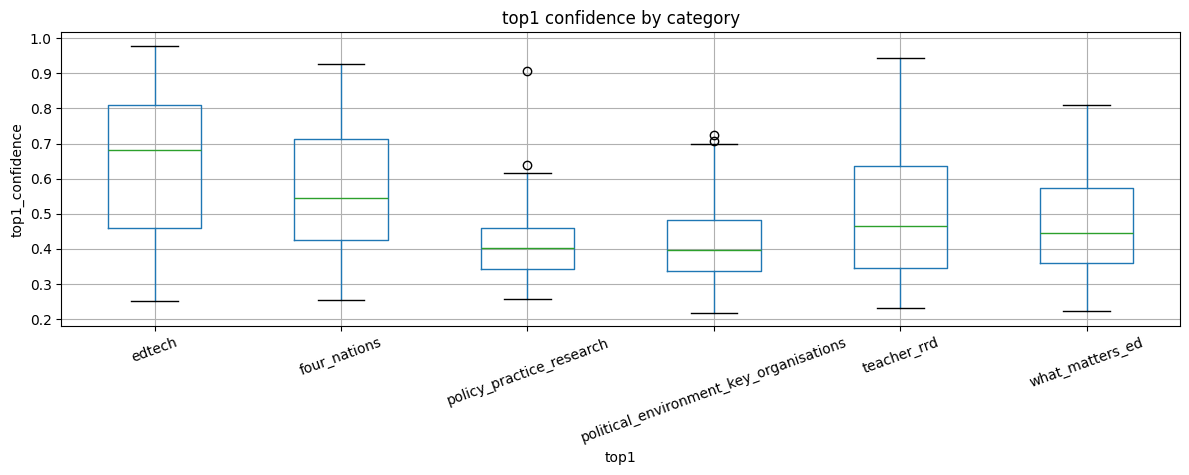

,count,mean,std,min,50%,max
top1,,,,,,
edtech,90.0,0.646,0.205,0.252,0.681,0.979
four_nations,135.0,0.563,0.168,0.255,0.544,0.925
policy_practice_research,45.0,0.424,0.120,0.257,0.403,0.907
political_environment_key_organisations,229.0,0.419,0.112,0.219,0.398,0.725
teacher_rrd,135.0,0.514,0.202,0.232,0.464,0.945
what_matters_ed,215.0,0.468,0.137,0.223,0.446,0.809


In [22]:
# Confidence by category — which classes the model is shakiest on
clean.boxplot(column="top1_confidence", by="top1", figsize=(12, 5), rot=20)
plt.title("top1 confidence by category"); plt.suptitle(""); plt.ylabel("top1_confidence")
plt.tight_layout(); plt.show()
clean.groupby("top1")["top1_confidence"].describe()[["count", "mean", "std", "min", "50%", "max"]].round(3)

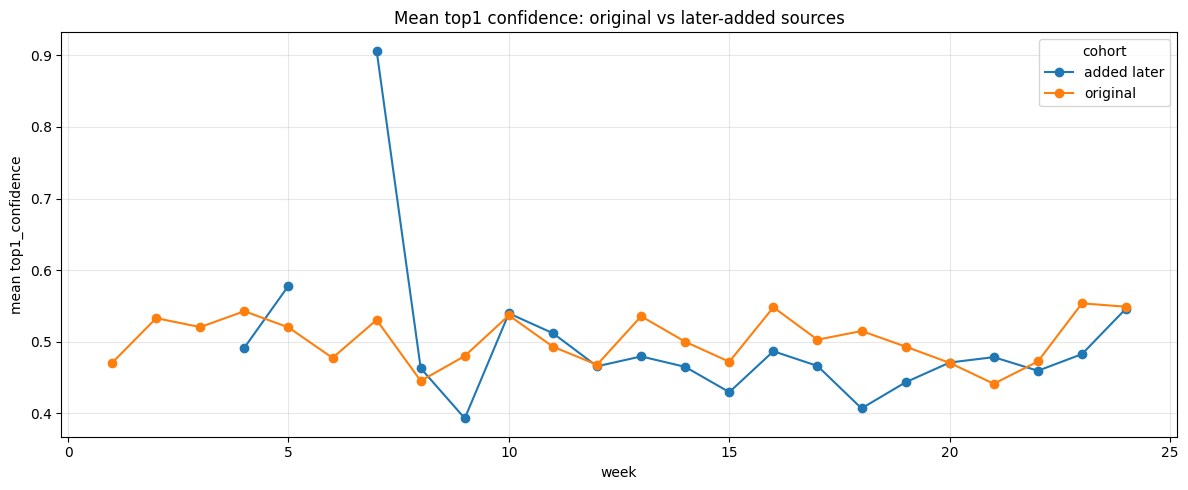

Articles per cohort per week (read confidence with this in mind):


_cohort,added later,original
_week,,
1,0,4
2,0,20
3,0,24
4,5,25
5,2,27
6,0,17
7,1,22
8,3,19
9,2,28


In [23]:
# Original vs later-added sources — separates real concept drift from new-source noise.
# Cells with very few articles are noisy; counts shown alongside.
first_seen = clean.groupby("source")["_week"].min()
original = set(first_seen[first_seen <= 3].index)
clean["_cohort"] = np.where(clean["source"].isin(original), "original", "added later")

coh = clean.groupby(["_week", "_cohort"])["top1_confidence"].mean().unstack()
coh_n = clean.groupby(["_week", "_cohort"]).size().unstack(fill_value=0)
coh.plot(figsize=(12, 5), marker="o",
         title="Mean top1 confidence: original vs later-added sources")
plt.ylabel("mean top1_confidence"); plt.xlabel("week"); plt.grid(alpha=0.3)
plt.legend(title="cohort"); plt.tight_layout(); plt.show()
print("Articles per cohort per week (read confidence with this in mind):")
coh_n

# Majojrity vs minority top1 

In [24]:
maj = clean["top1_confidence"] >= 0.5
print(f"top1 is a MAJORITY (>=0.5):  {maj.mean()*100:.0f}%")
print(f"top1 is a PLURALITY (<0.5):  {(~maj).mean()*100:.0f}%")

top1 is a MAJORITY (>=0.5):  40%
top1 is a PLURALITY (<0.5):  60%


In [25]:
clean["_rest_mass"] = (1 - clean["top1_confidence"] - clean["top2_confidence"]).clip(lower=0)
clean[["top1_confidence", "top2_confidence", "_rest_mass"]].mean().round(3)

top1_confidence    0.494
top2_confidence    0.206
_rest_mass         0.300
dtype: float64

In [26]:
def regime(r):
    if r.top1_confidence >= 0.5:                       return "decisive (top1 majority)"
    if r.top1_confidence + r.top2_confidence >= 0.6:   return "two-horse race"
    return "scattered (no idea)"
clean["_regime"] = clean.apply(regime, axis=1)
clean["_regime"].value_counts(normalize=True).mul(100).round(0)


_regime
decisive (top1 majority)    40.0
two-horse race              35.0
scattered (no idea)         25.0
Name: proportion, dtype: float64

In [27]:
pd.crosstab(clean["top1"], clean["_regime"], normalize="index").round(2)

_regime,decisive (top1 majority),scattered (no idea),two-horse race
top1,,,
edtech,0.70,0.10,0.20
four_nations,0.58,0.10,0.32
policy_practice_research,0.20,0.29,0.51
political_environment_key_organisations,0.23,0.32,0.45
teacher_rrd,0.44,0.27,0.29
what_matters_ed,0.39,0.23,0.38


## §8 — Combined / top2 confidence

Looking beyond the single top prediction:
- **top1 vs top2** mean per week — how much the runner-up trails the winner.
- **top-2 mass** (top1 + top2) — how much probability the model concentrates in its best two
  guesses; if this stays high while top1 falls, the model is *uncertain between two classes*,
  not lost.
- **confidence_gap** (top1 − top2) — decisiveness; a narrowing gap = the model dithering.
- **top1 ↔ top2 confusion** — which category pairs the model conflates.

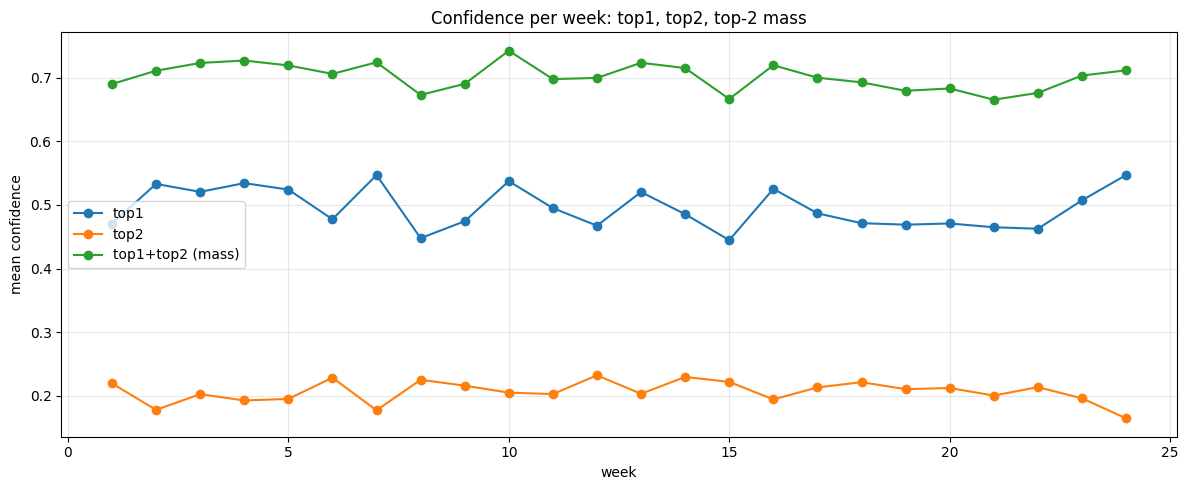

,top1_confidence,top2_confidence,_top2_mass
_week,,,
1,0.471,0.219,0.690
2,0.533,0.178,0.711
3,0.520,0.203,0.723
4,0.534,0.193,0.727
5,0.524,0.195,0.719
6,0.477,0.228,0.706
7,0.547,0.177,0.724
8,0.448,0.225,0.673
9,0.474,0.216,0.690


In [28]:
# top1, top2, and top-2 mass per week
clean["_top2_mass"] = clean["top1_confidence"] + clean["top2_confidence"]
wk_conf = clean.groupby("_week")[["top1_confidence", "top2_confidence", "_top2_mass"]].mean()
wk_conf.plot(figsize=(12, 5), marker="o", title="Confidence per week: top1, top2, top-2 mass")
plt.ylabel("mean confidence"); plt.xlabel("week"); plt.grid(alpha=0.3)
plt.legend(["top1", "top2", "top1+top2 (mass)"]); plt.tight_layout(); plt.show()
wk_conf.round(3)

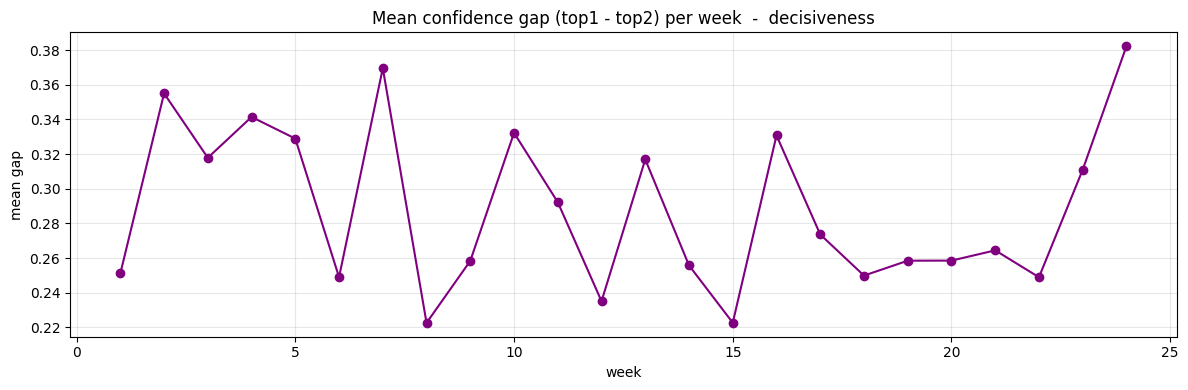

In [29]:
# Decisiveness: mean confidence_gap (top1 - top2) per week
clean.groupby("_week")["confidence_gap"].mean().plot(
    figsize=(12, 4), marker="o", color="purple",
    title="Mean confidence gap (top1 - top2) per week  -  decisiveness")
plt.ylabel("mean gap"); plt.xlabel("week"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

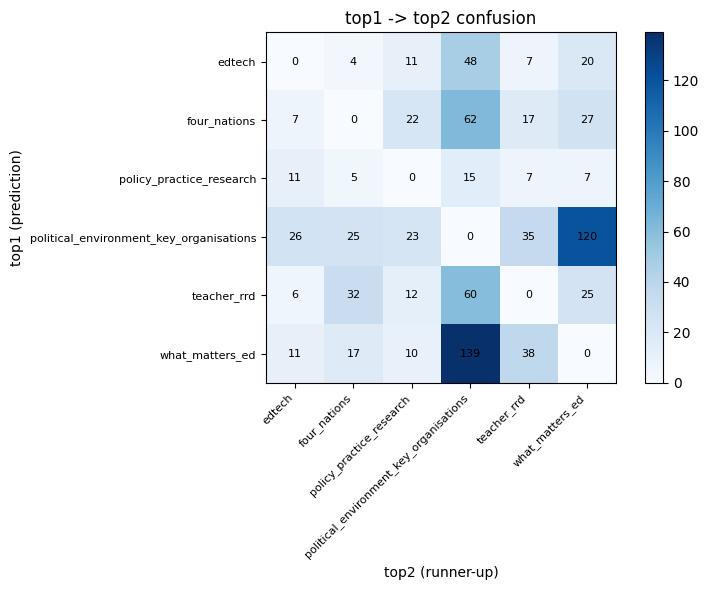

top2,edtech,four_nations,policy_practice_research,political_environment_key_organisations,teacher_rrd,what_matters_ed
top1,,,,,,
edtech,0,4,11,48,7,20
four_nations,7,0,22,62,17,27
policy_practice_research,11,5,0,15,7,7
political_environment_key_organisations,26,25,23,0,35,120
teacher_rrd,6,32,12,60,0,25
what_matters_ed,11,17,10,139,38,0


In [30]:
# top1 <-> top2 confusion: when the model predicts X, what's its usual runner-up?
confusion = pd.crosstab(clean["top1"], clean["top2"])
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(confusion.values, cmap="Blues")
ax.set_xticks(range(len(confusion.columns))); ax.set_xticklabels(confusion.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(confusion.index))); ax.set_yticklabels(confusion.index, fontsize=8)
ax.set_xlabel("top2 (runner-up)"); ax.set_ylabel("top1 (prediction)")
ax.set_title("top1 -> top2 confusion")
for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        ax.text(j, i, confusion.values[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()
confusion

# Volumne x Confidence 

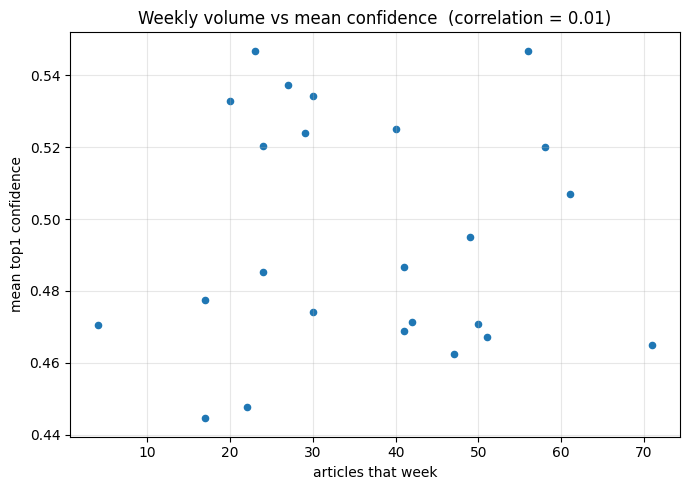

Pearson correlation: 0.01  (near 0 = no relationship)


In [31]:
# Volume vs confidence per week — is a busy week a less-confident week?
wk_stats = clean.groupby("_week").agg(
    volume=("top1", "size"),
    mean_conf=("top1_confidence", "mean"),
)
r = wk_stats["volume"].corr(wk_stats["mean_conf"])

ax = wk_stats.plot.scatter(x="volume", y="mean_conf", figsize=(7, 5))
ax.set_title(f"Weekly volume vs mean confidence  (correlation = {r:.2f})")
ax.set_xlabel("articles that week"); ax.set_ylabel("mean top1 confidence"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Pearson correlation: {r:.2f}  (near 0 = no relationship)")

## §9 — Drift synthesis

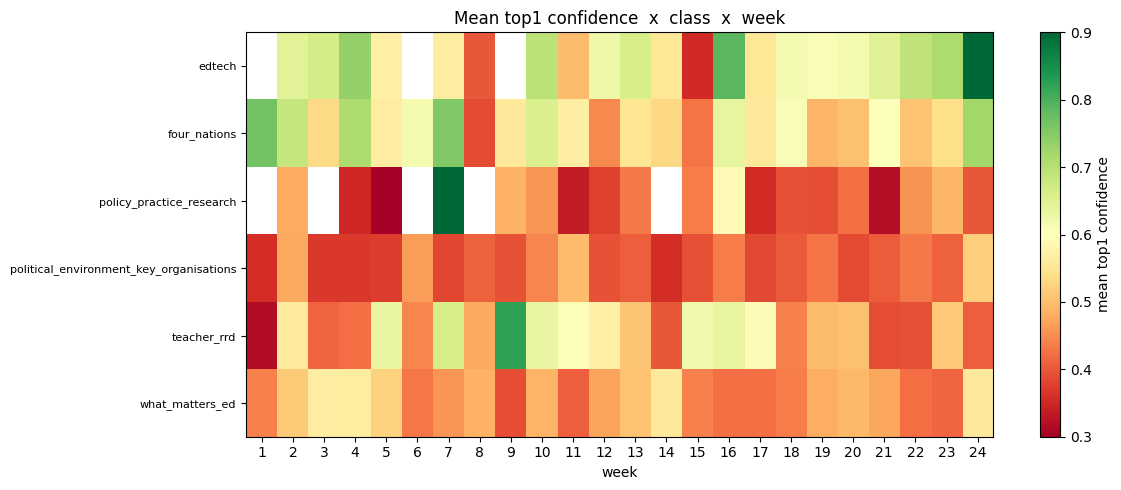

In [32]:
# Confidence x class x week heatmap — where uncertainty concentrates
class_conf = clean.groupby(["_week", "top1"])["top1_confidence"].mean().unstack()
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(class_conf.T.values, aspect="auto", cmap="RdYlGn", vmin=0.3, vmax=0.9)
ax.set_xticks(range(len(class_conf.index))); ax.set_xticklabels(class_conf.index)
ax.set_yticks(range(len(class_conf.columns))); ax.set_yticklabels(class_conf.columns, fontsize=8)
ax.set_xlabel("week"); ax.set_title("Mean top1 confidence  x  class  x  week")
plt.colorbar(im, ax=ax, label="mean top1 confidence")
plt.tight_layout(); plt.savefig(OUT_DIR / "drift_confidence_heatmap.png", dpi=120); plt.show()

### Findings

Fill these in from the cells above when you run it (numbers will update with the latest weeks):

1. **Volume** grew from a handful/week early on to ~100/week — driven by *new sources*
   switching on (see §3 unique-sources plot), not more from existing outlets.
2. **Confidence** (§7) — is the top1 trend actually down, or flat-and-noisy once you account
   for the changing source mix? Compare the original-cohort line (§7) against the overall.
   *Be honest: in this data it looks closer to flat than to the earlier 0.53->0.45 claim.*
3. **Composition vs concept drift** — the original-cohort confidence line is the control: if
   it's flat while "added later" drags the average, the apparent drift is mostly new-source
   composition, not the model degrading on its original beat.
4. **Category mix** (§5 normalised) — which classes are gaining/losing share.
5. **Coverage bias** (§6) — Wales ~1% of articles; Four Nations gap is a yield problem.
6. **Data quality** (§1) — off-topic escapes already blocked at source; ~1% of historical rows.

**For AM2 (S24):** these plots are evidence the monitoring infrastructure works. The
retraining decision (per `project-model-v1-and-v2-plan`: don't retrain pre-AM2) is
deliberate; v2 trigger criteria live in `docs/decisions/model_v1_state_and_retraining_plan.md`.

**Distinction angle (S22/S24):** monitoring + data-quality work surfaces drift and coverage
bias *before* they degrade production quality — that's the robustness story.

## §10 — Artefacts out

In [33]:
# Remove-list of dropped domains (all now blocked/paywalled in relevance.py; for the record)
pd.Series(sorted(DROPPED), name="source").to_csv(QUAL_DIR / "junk_sources.csv", index=False)

# Clean analysis dataset
clean.to_csv(QUAL_DIR / "inference_clean.csv", index=False)

print("Wrote:")
print(f"  {QUAL_DIR / 'junk_sources.csv'}  ({len(DROPPED)} domains)")
print(f"  {QUAL_DIR / 'inference_clean.csv'}  ({len(clean)} rows)")
print(f"PNGs in {OUT_DIR}: drift_class_mix, drift_confidence_over_time, "
      "drift_low_confidence_pct, drift_confidence_heatmap")

Wrote:
  /workspaces/AM2_erp_programme_automataion/data/quality/junk_sources.csv  (12 domains)
  /workspaces/AM2_erp_programme_automataion/data/quality/inference_clean.csv  (874 rows)
PNGs in /workspaces/AM2_erp_programme_automataion/outputs: drift_class_mix, drift_confidence_over_time, drift_low_confidence_pct, drift_confidence_heatmap


# §11 — Relevance filter analysis

*(folded in from former notebook 15 — keyword-filter tuning / data quality, a monitoring concern)*

## Cell 1 — Setup

In [34]:
from pathlib import Path
from collections import Counter
import re

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "modelling"

print("Notebook 14 — relevance keyword analysis")

Notebook 14 — relevance keyword analysis


## Cell 2 — Load curator-approved corpus (train + val)

In [35]:
train = pd.read_csv(DATA / "train.csv")
val = pd.read_csv(DATA / "val.csv")
nl = pd.concat([train, val], ignore_index=True)

print(f"Combined corpus: {len(nl)} curator-published items")
print(f"  Date range: {nl['issue_date'].min()} -> {nl['issue_date'].max()}")
print(f"\nSample 'text' field:")
print(nl["text"].iloc[0][:300])

Combined corpus: 1109 curator-published items
  Date range: 09 October 2023 -> 9 May 2025

Sample 'text' field:
SchoolsWeek analyses five key findings on the teacher workforce from The School Teachers' Review Body's Report 


## Cell 3 — Tokenize, count unigrams + bigrams

In [36]:
TOKEN_RE = re.compile(r"[a-z][a-z'-]+[a-z]")

STOPWORDS = set('''
a about above after again against all am an and any are as at be because been before
being below between both but by can cannot could did do does doing don down during
each few for from further had has have having he her here hers herself him himself
his how i if in into is it its itself just like me more most my myself no nor not
now of off on once only or other our ours ourselves out over own same she should
so some such than that the their theirs them themselves then there these they this
those through to too under until up very was we were what when where which while
who whom why will with would you your yours yourself yourselves
also one new use using used would could may say says said also however been per get
year years week last next time make made take taken get got see seen go going gone
say says said way ways need needs needed find found set sets setting still well good
much many lot lots well even must might shall let going us off via through into among
across down up around back forth without within across despite although though since
yet thus hence therefore moreover furthermore yes no maybe perhaps probably possibly
think thought know knew look looked tell told ask asked want wanted try tried like
liked feel felt seem seemed appear appeared become became come came give gave got
keep kept put bring brought show showed made make help helped work worked called
called help helped help help one two three four five six seven eight nine ten today
'''.split())

def tokenize(text):
    if not isinstance(text, str): return []
    return [t for t in TOKEN_RE.findall(text.lower()) if t not in STOPWORDS]

def bigrams(tokens):
    return [f"{a} {b}" for a, b in zip(tokens, tokens[1:])]

unigram_counts = Counter()
bigram_counts = Counter()
for txt in nl["text"].dropna():
    toks = tokenize(txt)
    unigram_counts.update(toks)
    bigram_counts.update(bigrams(toks))

print(f"Total tokens: {sum(unigram_counts.values()):,}")
print(f"Unique unigrams: {len(unigram_counts):,}")
print(f"Unique bigrams: {len(bigram_counts):,}")

print(f"\nTop 60 unigrams:")
for term, c in unigram_counts.most_common(60):
    print(f"  {term:<30} {c:>5}")

print(f"\nTop 40 bigrams:")
for bg, c in bigram_counts.most_common(40):
    print(f"  {bg:<40} {c:>5}")

Total tokens: 28,368
Unique unigrams: 5,449
Unique bigrams: 21,253

Top 60 unigrams:
  education                        607
  schools                          382
  report                           295
  school                           286
  research                         242
  government                       236
  children                         229
  teachers                         219
  policy                           201
  teacher                          186
  support                          169
  evidence                         113
  england                          111
  impact                           111
  blog                             110
  send                             110
  schoolsweek                      107
  dfe                              106
  funding                          104
  learning                          99
  young                             98
  pupils                            96
  teaching                          95
  review          

## Cell 4 — Candidate keyword list

The list below was hand-curated from the unigram + bigram analysis above.
Edit it here in the notebook, re-run cells below to test, then **copy the final
list into `src/scraping/relevance.py`** as `DEFAULT_EDUCATION_KEYWORDS`.

In [37]:
KEYWORDS = [
    # Core schools + sectors
    "school", "schools", "pupil", "pupils", "student", "students",
    "teacher", "teachers", "teaching", "classroom",
    "primary", "secondary", "nursery", "early years", "eyfs",
    "academy", "academies", "trust", "trusts",
    "college", "colleges", "further education", "sixth form",
    "university", "universities", "higher education", "campus",
    "education", "educational",
    # Curriculum & assessment
    "curriculum", "gcse", "a-level", "a level", "phonics",
    "literacy", "numeracy", "stem",
    "ofsted", "ofqual", "inspection",
    "exam", "exams", "examination",
    # SEND & inclusion (UK + Scottish terms)
    "send", "ehcp", "special needs", "special educational",
    "additional support for learning", "asl", "additional support needs", "asn",
    "alternative provision",
    "disability", "disabilities",
    "free school meals", "fsm", "disadvantage", "disadvantaged",
    "attendance",
    "safeguarding", "online safety", "behaviour", "exclusion", "exclusions",
    # Workforce
    "recruitment", "retention", "training", "cpd",
    "headteacher", "head teacher",
    "professional learning",
    "early career framework", "ecf",
    "governance", "trustees",
    # Policy bodies / actors
    "dfe", "department for education", "department education",
    "schools week", "schoolsweek",
    "select committee", "education committee",
    "minister", "education minister", "education secretary",
    # Pedagogy / research
    "research", "evidence-based", "pedagogy",
    "education research", "education policy",
    # Demographic / broader
    "child", "children", "young people", "youth",
    "skills", "apprenticeship", "apprenticeships",
    # Specific frequently-newslettered topics
    "white paper", "schools bill", "curriculum assessment",
    "child poverty", "mental health", "wellbeing",
]

def compile_patterns(kws):
    pats = []
    for kw in kws:
        kw_l = kw.lower().strip()
        if " " in kw_l or "-" in kw_l:
            pats.append((kw_l, re.compile(rf"(?<!\w){re.escape(kw_l)}(?!\w)")))
        else:
            pats.append((kw_l, re.compile(rf"\b{re.escape(kw_l)}\b")))
    return pats

patterns = compile_patterns(KEYWORDS)

def matches(text):
    if not isinstance(text, str): return False
    t = text.lower()
    return any(p.search(t) for _, p in patterns)

print(f"Candidate keyword list: {len(KEYWORDS)} keywords")

Candidate keyword list: 103 keywords


## Cell 5 — Test the filter on the 854 backfill articles

In [38]:
clf = pd.read_csv(DATA / "classified_articles.csv")
clf["_haystack"] = (clf["title"].fillna("") + " " + clf["text_clean"].fillna("")).str.lower()
clf["passes"] = clf["_haystack"].apply(matches)

print(f"Filter test on {len(clf)} articles:")
print(f"  Keep:   {clf['passes'].sum()} ({clf['passes'].mean()*100:.1f}%)")
print(f"  Reject: {(~clf['passes']).sum()} ({(~clf['passes']).mean()*100:.1f}%)")

print(f"\nPer-source pass rate (sources with >=5 articles, sorted lowest-first):")
by_src = clf.groupby("source").agg(n=("url","size"), n_pass=("passes","sum"))
by_src["pct_pass"] = (by_src["n_pass"] / by_src["n"] * 100).round(1)
by_src["n_reject"] = by_src["n"] - by_src["n_pass"]
by_src = by_src[by_src["n"] >= 5].sort_values("pct_pass")
print(by_src.to_string())

Filter test on 849 articles:
  Keep:   845 (99.5%)
  Reject: 4 (0.5%)

Per-source pass rate (sources with >=5 articles, sorted lowest-first):
                                               n  n_pass  pct_pass  n_reject
source                                                                      
ucl_ioe_blog                                  12      10      83.3         2
sutton_trust                                  17      16      94.1         1
ascl                                          49      48      98.0         1
ades                                          10      10     100.0         0
children_in_scotland                          23      23     100.0         0
children_s_commissioner                       16      16     100.0         0
bbc.co.uk                                     10      10     100.0         0
belfast_telegraph                             66      66     100.0         0
education-ni.gov.uk                            9       9     100.0         0
epi        

## Cell 6 — Sanity check: all curator-published articles must pass

If any curator-approved article gets rejected by the filter, the keyword list is too narrow.

In [39]:
def norm_url(u):
    if not isinstance(u, str): return None
    u = u.strip().lower()
    u = re.sub(r"^https?://(www\.)?", "", u).rstrip("/")
    u = re.sub(r"[?#].*$", "", u)
    return u or None

nl_urls = set(filter(None, (norm_url(u) for u in nl["link"].dropna())))
clf["_norm_url"] = clf["url"].apply(norm_url)
clf["in_nl"] = clf["_norm_url"].isin(nl_urls)
pub = clf[clf["in_nl"]]

print(f"Sanity check — {len(pub)} curator-published articles in backfill:")
print(f"  Pass filter: {pub['passes'].sum()} / {len(pub)}")
if (~pub["passes"]).any():
    print(f"\n⚠ FALSE NEGATIVES (published but filtered out — keywords too narrow):")
    for _, r in pub[~pub["passes"]].iterrows():
        print(f"  {r['url']}")
        print(f"    title: {r['title']}")
else:
    print(f"  ✓ All curator-published articles pass the filter")

Sanity check — 4 curator-published articles in backfill:
  Pass filter: 4 / 4
  ✓ All curator-published articles pass the filter


## Cell 7 — Inspect rejected articles + save audit CSV

Save the rejected list to `data/archive/rejected/<date>_filter-test.csv`. Then
eyeball the top-confidence rejections — those are the most likely false negatives.

In [40]:
rejected = clf[~clf["passes"]][["url", "title", "source", "article_date",
                                  "top1", "top1_confidence"]].copy()
out_path = Path("data/archive/rejected/2026-05-17_filter-test.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
rejected.to_csv(out_path, index=False)
print(f"Saved {len(rejected)} rejected articles to {out_path}")

print(f"\nTop 15 rejected sorted by classifier top1_confidence")
print(f"(high confidence in rejected = potential false negative — review):")
hc = rejected.nlargest(15, "top1_confidence")
for _, r in hc.iterrows():
    print(f"  conf={r['top1_confidence']:.2f}  [{r['source']}]  {str(r['title'])[:110]}")

Saved 4 rejected articles to data/archive/rejected/2026-05-17_filter-test.csv

Top 15 rejected sorted by classifier top1_confidence
(high confidence in rejected = potential false negative — review):
  conf=0.87  [ucl_ioe_blog]  How to test AI’s deceits
  conf=0.58  [ascl]  ASCL General Secretary's address to ASCL Annual Conference 2026
  conf=0.56  [ucl_ioe_blog]  The concept and practice of evidence and evidencing: misuses and misconceptions
  conf=0.46  [sutton_trust]  Breaking the mould: A social mobility journey through the arts and humanities?


## Cell 8 — How to update production

After hand-curating `KEYWORDS` above:

1. Copy the final `KEYWORDS` list into `src/scraping/relevance.py` as `DEFAULT_EDUCATION_KEYWORDS`
2. In `src/scraping/sources.yml`, add `apply_relevance_filter: true` to the `params` block of any broad source:
   ```yaml
   - name: belfast_telegraph
     type: rss
     scraper: src.scraping.rss_adapter
     params:
       feed_url: ...
       apply_relevance_filter: true
   ```
3. Re-run the scraper. Rejected articles appear in `data/archive/rejected/<date>_<source>.csv` per source per run.

Narrow sources (`schoolsweek`, `ofsted`, `epi`, `eef`, `nfer`, etc.) don't need
this filter — their feeds are pure education already (see cell 5 pass rates).

# §12 — Production monitoring review surface

The sections above **recompute** drift from the raw `v_dashboard` data. This section instead **pulls the pipeline's already-computed monitoring records** from Supabase (the actual production history the weekly jobs wrote), plus a **retrain-trigger check**. This is the weekly/monthly *review surface* — what you'd glance at to answer "is the model still OK, and is it due a retrain?"

In [41]:
# Pull the pipeline's computed monitoring history from Supabase.
import os
from dotenv import load_dotenv
from supabase import create_client
load_dotenv(ROOT / ".env")
sb = create_client(os.environ["SUPABASE_URL"], os.environ["SUPABASE_SERVICE_KEY"])

# fairness_log = the weekly monitoring metrics (confidence, disparity, class mix) over time.
fl = pd.DataFrame(sb.table("fairness_log").select("*").order("computed_at").execute().data)
fl["computed_at"] = pd.to_datetime(fl["computed_at"])
print(f"fairness_log: {len(fl)} production monitoring runs "
      f"({fl['computed_at'].min().date()} -> {fl['computed_at'].max().date()})")
fl[["computed_at", "n_articles", "mean_top1_confidence", "pct_below_50",
    "source_confidence_disparity", "most_predicted_class", "least_predicted_class"]].tail(10)

fairness_log: 16 production monitoring runs (2026-05-18 -> 2026-06-11)


,computed_at,n_articles,mean_top1_confidence,pct_below_50,source_confidence_disparity,most_predicted_class,least_predicted_class
6,2026-05-25 03:50:14.538963+00:00,986,0.478904,0.625761,0.610400,political_environment_key_organisations,policy_practice_research
7,2026-05-26 03:49:28.303774+00:00,991,0.476770,0.631685,0.610400,political_environment_key_organisations,policy_practice_research
8,2026-05-27 03:48:13.078614+00:00,776,0.482636,0.618557,0.496305,political_environment_key_organisations,policy_practice_research
9,2026-05-28 12:20:34.440336+00:00,794,0.481328,0.622166,0.478601,political_environment_key_organisations,policy_practice_research
10,2026-05-28 12:35:00.199876+00:00,795,0.481687,0.621384,0.478601,political_environment_key_organisations,policy_practice_research
11,2026-05-29 11:33:05.834816+00:00,761,0.485117,0.611038,0.478601,political_environment_key_organisations,policy_practice_research
12,2026-06-02 04:23:45.046497+00:00,774,0.487788,0.603359,0.468059,political_environment_key_organisations,policy_practice_research
13,2026-06-09 04:17:33.981194+00:00,836,0.489707,0.601675,0.468059,political_environment_key_organisations,policy_practice_research
14,2026-06-10 04:35:39.572287+00:00,840,0.491865,0.594048,0.468059,political_environment_key_organisations,policy_practice_research
15,2026-06-11 04:26:52.907796+00:00,849,0.493669,0.591284,0.468059,political_environment_key_organisations,policy_practice_research


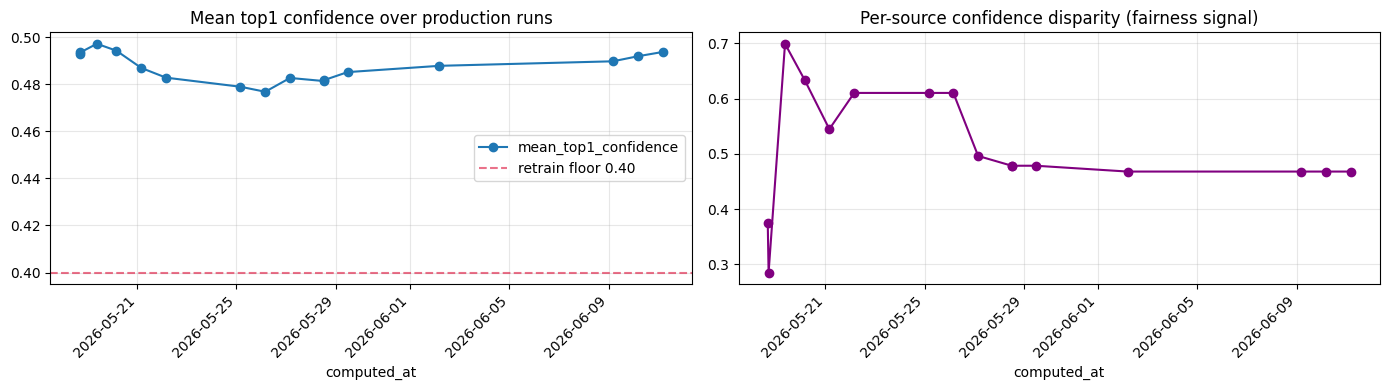

In [42]:
# Monitoring trend across production runs (the real history, not a recompute)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
fl.plot(x="computed_at", y="mean_top1_confidence", marker="o", ax=ax[0], legend=False,
        title="Mean top1 confidence over production runs")
ax[0].axhline(0.40, color="crimson", ls="--", alpha=0.6, label="retrain floor 0.40")
ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].tick_params(axis="x", rotation=45)
fl.plot(x="computed_at", y="source_confidence_disparity", marker="o", color="purple", ax=ax[1],
        legend=False, title="Per-source confidence disparity (fairness signal)")
ax[1].grid(alpha=0.3); ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

In [43]:
# drift_log — s09_monitor's drift records (currently empty: the monitor logs to
# monitoring_log.csv / the GitHub Actions summary, not this table yet).
dl = pd.DataFrame(sb.table("drift_log").select("*").execute().data)
print(f"drift_log: {len(dl)} rows")
if len(dl) == 0:
    print("  (empty — s09_monitor writes monitoring_log.csv + Actions summary, not drift_log.")
    print("   Wiring s09 -> drift_log is part of the monitoring redesign, docs/decisions/monitoring_redesign_2026_06_11.md)")
dl.tail(10) if len(dl) else None

drift_log: 24 rows


,id,run_id,batch_id,computed_at,week_start,week_end,n_articles,mean_confidence,median_confidence,pct_below_50,pct_below_30,mean_similarity,min_similarity,n_drift_flagged,class_distribution,distribution_alerts
14,b49d4d92-8812-4e30-a930-3320673c4cdf,v1_2026-05-16,backfill_w15,2026-06-11T23:26:43.838179+00:00,2026-04-07,2026-04-13,17,0.444533,0.373497,0.823529,0.117647,0.529532,0.336866,0,"{'edtech': 0.058823529411764705, 'teacher_rrd'...",[what_matters_ed: 19.2% → 47.1% (delta +27.9%)]
15,34927e89-f361-4023-8005-a63a115e5048,v1_2026-05-16,backfill_w16,2026-06-11T23:26:43.838179+00:00,2026-04-14,2026-04-20,40,0.525090,0.457952,0.550000,0.075000,0.538803,0.228083,2,"{'edtech': 0.1, 'teacher_rrd': 0.2, 'four_nati...",[policy_practice_research: 14.4% → 2.5% (delta...
16,39301977-cb1b-4bfa-9b0e-56fd44147ca1,v1_2026-05-16,backfill_w17,2026-06-11T23:26:43.838179+00:00,2026-04-21,2026-04-24,41,0.486740,0.439700,0.658537,0.121951,0.538512,0.315661,0,"{'edtech': 0.14634146341463414, 'teacher_rrd':...",[policy_practice_research: 14.4% → 2.4% (delta...
17,a9985587-0ba1-487c-bce5-910f48ab0ebb,v1_2026-05-16,backfill_w18,2026-06-11T23:26:43.838179+00:00,2026-04-28,2026-05-04,42,0.471226,0.418111,0.619048,0.142857,0.537021,0.354807,0,"{'edtech': 0.07142857142857142, 'teacher_rrd':...",[policy_practice_research: 14.4% → 2.4% (delta...
18,e4a2313f-fae6-4eb4-820a-274b2855ae55,v1_2026-05-16,backfill_w19,2026-06-11T23:26:43.838179+00:00,2026-05-05,2026-05-11,41,0.468872,0.418380,0.658537,0.073171,0.494212,0.257779,2,"{'edtech': 0.12195121951219512, 'teacher_rrd':...",[political_environment_key_organisations: 17.4...
19,97b55d03-49ad-4995-978d-55ade5c8f72c,v1_2026-05-16,backfill_w20,2026-06-11T23:26:43.838179+00:00,2026-05-12,2026-05-18,50,0.470747,0.439426,0.740000,0.100000,0.509155,0.267126,2,"{'edtech': 0.12, 'teacher_rrd': 0.06, 'four_na...",[political_environment_key_organisations: 17.4...
20,4a582ec4-e73b-43a1-b8d1-aa197108cad7,v1_2026-05-16,backfill_w21,2026-06-11T23:26:43.838179+00:00,2026-05-19,2026-05-25,71,0.464844,0.416814,0.577465,0.140845,0.554690,0.313153,0,"{'edtech': 0.08450704225352113, 'teacher_rrd':...",[policy_practice_research: 14.4% → 4.2% (delta...
21,e37c55c1-0cce-4b1e-afd0-e0781327bc46,v1_2026-05-16,backfill_w22,2026-06-11T23:26:43.838179+00:00,2026-05-26,2026-06-01,47,0.462473,0.424408,0.680851,0.170213,0.501944,0.316785,0,"{'edtech': 0.10638297872340426, 'teacher_rrd':...",[political_environment_key_organisations: 17.4...
22,5356d71f-ae54-4d8a-88e1-5cf48a9b3061,v1_2026-05-16,backfill_w23,2026-06-11T23:26:43.838179+00:00,2026-06-02,2026-06-08,61,0.507118,0.452973,0.590164,0.131148,0.516177,0.312165,0,"{'edtech': 0.16393442622950818, 'teacher_rrd':...",[policy_practice_research: 14.4% → 3.3% (delta...
23,2dae13e3-df99-48e7-b478-2924f138af8c,v1_2026-05-16,backfill_w24,2026-06-11T23:26:43.838179+00:00,2026-06-09,2026-06-11,31,0.546876,0.558469,0.483871,0.064516,0.569484,0.408328,0,"{'edtech': 0.03225806451612903, 'teacher_rrd':...","[edtech: 15.6% → 3.2% (delta -12.3%), what_mat..."


## Retrain-trigger check

Checks the live data + Supabase against the **3 documented triggers** (`docs/decisions/model_v1_state_and_retraining_plan.md`). Retrain only when **ALL three** are met.

In [44]:
# Retrain-trigger check — are ALL 3 documented triggers met?
# Trigger 1: >= 500 curator decisions accumulated (fresh labels for a fair v1-vs-v2 compare)
n_decisions = sb.table("curator_decisions").select("id", count="exact").execute().count

# Trigger 2: >= 4 weeks since v1 deployed (active.txt -> v1_2026-05-16)
deploy = pd.Timestamp("2026-05-16")
weeks_since = (pd.Timestamp(all_df["article_date"].max()) - deploy).days / 7

# Trigger 3: weekly mean top1 confidence < 0.40 for 2 consecutive weeks
wkconf = clean.groupby("_week")["top1_confidence"].mean()
below = wkconf < 0.40
t1, t2, t3 = n_decisions >= 500, weeks_since >= 4, bool((below & below.shift(1)).any())

print("RETRAIN-TRIGGER CHECK  (retrain only if ALL three are MET)\n" + "-" * 56)
print(f"  1. curator decisions >= 500 : {n_decisions:>4} / 500           -> {'MET' if t1 else 'not met'}")
print(f"  2. >= 4 weeks since deploy  : {weeks_since:>4.1f} / 4 weeks       -> {'MET' if t2 else 'not met'}")
print(f"  3. conf <0.40 x2 wks        : min weekly conf {wkconf.min():.3f}    -> {'MET' if t3 else 'not met'}")
print("-" * 56)
print(f"  >>> RETRAIN DUE: {'YES' if (t1 and t2 and t3) else 'NO'}")

RETRAIN-TRIGGER CHECK  (retrain only if ALL three are MET)
--------------------------------------------------------
  1. curator decisions >= 500 :   98 / 500           -> not met
  2. >= 4 weeks since deploy  :  3.7 / 4 weeks       -> not met
  3. conf <0.40 x2 wks        : min weekly conf 0.445    -> not met
--------------------------------------------------------
  >>> RETRAIN DUE: NO
